In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
# Define the state 
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [3]:
# Create a Function to Calculate BMI
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state["weight_kg"]
    height = state["height_m"]
    
    bmi = weight / (height ** 2)
    
    state["bmi"] = round(bmi, 2)
    
    return state

In [4]:
# Create a Function to Label BMI
def label_bmi(state: BMIState) -> BMIState:
    bmi = state["bmi"]
    
    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

In [5]:
# Define the graph
graph = StateGraph(BMIState)

# Add Nodes to Your Graph
graph.add_node("Calculate_BMI", calculate_bmi)
graph.add_node("Label_BMI", label_bmi)

# Add Eges to Your Graph
graph.add_edge(START, "Calculate_BMI")
graph.add_edge("Calculate_BMI", "Label_BMI")
graph.add_edge("Label_BMI", END)


# Compile the Graph
workflow = graph.compile()



In [6]:
# Execute the Graph
initial_state = {"weight_kg": 50, "height_m": 1.8}

final_state = workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 50, 'height_m': 1.8, 'bmi': 15.43, 'category': 'Underweight'}


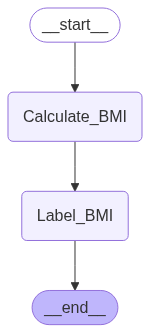

In [7]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())